# Partie I : Feature engineering à partir d'un proposition Kaggel  
[Lien vers le Kaggel](https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script)

## 1. Initialisation

### 1.1 Packages

In [1]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborne as sns

### 1.2 Fonctions

Preprocess fonctions issue de Kaggel

In [2]:
# HOME CREDIT DEFAULT RISK COMPETITION
# Most features are created by applying min, max, mean, sum and var functions to grouped tables. 
# Little feature selection is done and overfitting might be a problem since many features are related.
# The following key ideas were used:
# - Divide or subtract important features to get rates (like annuity and income)
# - In Bureau Data: create specific features for Active credits and Closed credits
# - In Previous Applications: create specific features for Approved and Refused applications
# - Modularity: one function for each table (except bureau_balance and application_test)
# - One-hot encoding for categorical features
# All tables are joined with the application DF using the SK_ID_CURR key (except bureau_balance).
# You can use LightGBM with KFold or Stratified KFold.

# Update 16/06/2018:
# - Added Payment Rate feature
# - Removed index from features
# - Use standard KFold CV (not stratified)

import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# from lightgbm import LGBMClassifier
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# One-hot encoding for categorical columns with get_dummies
def categorie_feature_encoder(df, nan_as_category = False):
    
    # Get the object type columns
    object_columns = df.select_dtypes("object").columns
    
    ## Count class in each columns and isolate the one with stricly less than three class
    tow_class_columns = []
    more_class_columns = []

    for column in object_columns:
        n_class = len(
                    df[column].unique()
                    )
        
        if n_class < 3:
            tow_class_columns.append(column)
            
        elif n_class >= 2 :
            more_class_columns.append(column)
    if nan_as_category:    
        ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=42)
        one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        
    else:
        ordinal_encoder = OrdinalEncoder()
        one_hot_encoder = OneHotEncoder(sparse_output=False)

    # For the exactly tow categories
    df_index = df[tow_class_columns].index
    ordinal_encoded = ordinal_encoder.fit_transform(df[tow_class_columns])
    tow_class_columns_encoded = ordinal_encoder.get_feature_names_out()
    ordinal_encoded = pd.DataFrame(ordinal_encoded, columns = tow_class_columns_encoded, index=df_index)
    
    
    # For the more than tow catégories
    df_index = df[more_class_columns].index
    one_hot_encoded = one_hot_encoder.fit_transform(df[more_class_columns])
    more_class_columns_encoded = one_hot_encoder.get_feature_names_out()
    one_hot_encoded = pd.DataFrame(one_hot_encoded, columns = more_class_columns_encoded, index=df_index)
    
    # Remove the orignal columns
    df_out = df.drop(object_columns, axis=1)
    del df
    
    # Add the new
    df_out = pd.concat([df_out, ordinal_encoded], axis=1)
    df_out = pd.concat([df_out, one_hot_encoded], axis=1)

    # Recover he new columns names
    new_columns = np.append(tow_class_columns_encoded, more_class_columns_encoded)
    
    return df_out, new_columns

# Preprocess application_train.csv and application_test.csv
def application_train_test(data_directory, num_rows = None, nan_as_category = False):
    # Read data and merge
    df = pd.read_csv(f'{data_directory}/application_train.csv', nrows= num_rows)
    test_df = pd.read_csv(f'{data_directory}/application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    df = pd.concat([df, test_df], axis=0, ignore_index=True)

    # Optional: Remove 4 applications with XNA CODE_GENDER (train set)
    drop_index = df.loc[df["CODE_GENDER"] == "XNA"].index
    df = df.drop(drop_index)
    del drop_index
    
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = categorie_feature_encoder(df, nan_as_category)
    
    # NaN values for DAYS_EMPLOYED: 365.243 -> nan
    # Create an annomalie flag column 
    df['DAYS_EMPLOYED_ANOM'] = 0
    mask = df["DAYS_EMPLOYED"] == 365243
    df.loc[mask, "DAYS_EMPLOYED_ANOM"] = 1
    # Change value
    df.loc[mask, "DAYS_EMPLOYED"] = np.nan
    
    # Some simple new features (percentages)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    del test_df
    gc.collect()
    return df

# Preprocess bureau.csv and bureau_balance.csv
def bureau_and_balance(data_directory, num_rows = None, nan_as_category = True):
    bureau = pd.read_csv(f'{data_directory}/bureau.csv', nrows = num_rows)
    bb = pd.read_csv(f'{data_directory}/bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = categorie_feature_encoder(bb, nan_as_category)
    bureau, bureau_cat = categorie_feature_encoder(bureau, nan_as_category)
    
    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()
    
    # Bureau and bureau_balance numeric features
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg

# Preprocess previous_applications.csv
def previous_applications(data_directory, num_rows = None, nan_as_category = True):
    prev = pd.read_csv(f'{data_directory}/previous_application.csv', nrows = num_rows)
    prev, cat_cols = categorie_feature_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    
    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

# Preprocess POS_CASH_balance.csv
def pos_cash(data_directory, num_rows = None, nan_as_category = True):
    pos = pd.read_csv(f'{data_directory}/POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = categorie_feature_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg
    
# Preprocess installments_payments.csv
def installments_payments(data_directory, num_rows = None, nan_as_category = True):
    ins = pd.read_csv(f'{data_directory}/installments_payments.csv', nrows = num_rows)
    ins, cat_cols = categorie_feature_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

# Preprocess credit_card_balance.csv
def credit_card_balance(data_directory, num_rows = None, nan_as_category = True):
    cc = pd.read_csv(f'{data_directory}/credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = categorie_feature_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc
    gc.collect()
    return cc_agg

def main(data_directory, debug = False):
    '''
    Appliquer les différentes transformation précédente sur les données de l'étude.

    Return :
        df (dataframe) : dataframe qui contient le résultat des la combinaison et du feature engineering réaliser sur les données. 
    '''
    num_rows = 10000 if debug else None
    df = application_train_test(data_directory, num_rows)
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(data_directory, num_rows)
        print("Bureau df shape:", bureau.shape)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()
    with timer("Process previous_applications"):
        prev = previous_applications(data_directory, num_rows)
        print("Previous applications df shape:", prev.shape)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()
    with timer("Process POS-CASH balance"):
        pos = pos_cash(data_directory, num_rows)
        print("Pos-cash balance df shape:", pos.shape)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()
    with timer("Process installments payments"):
        ins = installments_payments(data_directory, num_rows)
        print("Installments payments df shape:", ins.shape)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()
    with timer("Process credit card balance"):
        cc = credit_card_balance(data_directory, num_rows)
        print("Credit card balance df shape:", cc.shape)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()
        
    return df      

## 2. Importation/transformation avec les fonctions de Kaggel

In [3]:
data_directory = r"./data/raw"
data = main(data_directory, debug=False)

Train samples: 307511, test samples: 48744
Bureau df shape: (305811, 112)
Process bureau and bureau_balance - done in 25s
Previous applications df shape: (338857, 234)
Process previous_applications - done in 24s
Pos-cash balance df shape: (337252, 17)
Process POS-CASH balance - done in 12s
Installments payments df shape: (339587, 26)
Process installments payments - done in 21s
Credit card balance df shape: (103558, 136)
Process credit card balance - done in 15s


In [4]:
data.shape

(356251, 778)

## 3. Exportation  
Sauvegarder le résultats pour ne pas le recalculer à chaque entrainement

### 3.1 Retirer les erreurs d'infini produit par la méthode

In [5]:
# Verifier la présence d'infinit
data.isin([np.inf, -np.inf]).any().value_counts()

False    771
True       7
Name: count, dtype: int64

In [6]:
# Identifier les colonnes

In [7]:
inf_column = data.columns[data.isin([np.inf, -np.inf]).any() ]

In [8]:
# Identifier les lignes
drop_index = np.array([])
for column in inf_column :
    index = data.loc[data[column].isin([np.inf, -np.inf]), column].index
    print(index)
    
    index = np.array(index)
    drop_index = np.append(drop_index, index)

drop_index = np.unique(drop_index)

Index([201086], dtype='int64')
Index([201086], dtype='int64')
Index([201086], dtype='int64')
Index([201086], dtype='int64')
Index([  5687,  60477,  79077,  89018,  98509, 126768, 128791, 140426, 152087,
       167136, 199103, 236164, 238381, 272829, 277962, 287300, 292852, 305373,
       310339],
      dtype='int64')
Index([  5687,  60477,  79077,  89018,  98509, 126768, 128791, 140426, 152087,
       167136, 199103, 236164, 238381, 272829, 277962, 287300, 292852, 305373,
       310339],
      dtype='int64')
Index([  5687,  60477,  79077,  89018,  98509, 126768, 128791, 140426, 152087,
       167136, 199103, 236164, 238381, 272829, 277962, 287300, 292852, 305373,
       310339],
      dtype='int64')


In [9]:
print(f"{len(drop_index)} lignes contiennent des valeurs inf")

20 lignes contiennent des valeurs inf


On vire toutes les lignes qui contiennent ces valeurs. Pourrai aussi les rendre null

In [10]:
data = data.drop(drop_index)
# Verifier la présence d'infinit
data.isin([np.inf, -np.inf]).any().value_counts()

False    778
Name: count, dtype: int64

In [11]:
del drop_index

### 3.2 Sauvegarde des résultats

In [12]:
out_directory = r"./data/transformed"

In [13]:
data.to_csv(os.path.join(out_directory,"train_data_V1.csv"), header=True, index=False)

### 3.3 Export d'un exemple d'une ligne

In [14]:
temp = data.loc[data["SK_ID_CURR"] == 281026, :]

In [16]:
temp.to_csv(os.path.join(out_directory, "test_dashboard_V1.csv"),
           index=False)

## 4. Nettoyer les variables

In [17]:
%reset -f

# Partie II : Entrainement du model suivie avec MlFlow

## 1. Initialisation

### 1.1 Package 

In [18]:
import os
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [19]:
# Construction des dataset
from sklearn.model_selection import train_test_split

In [87]:
# Pipeline

##from sklearn.pipeline import Pipeline

# Pour utiliser SMOTE dans un pipeline il faut prendre l'outil pipe de sk imbalance learn
from imblearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV # Recherche d'hyperparametre
from sklearn.model_selection import TunedThresholdClassifierCV # optmisation du seuil de décision
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [21]:
# Définition d'une metric
from sklearn.metrics import confusion_matrix, make_scorer, precision_score, recall_score

In [22]:
# Réduction de dimension
from sklearn.decomposition import PCA

In [23]:
# Synthetic Minority Oversampling Technique SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [24]:
# Modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [25]:
# MlFlow
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature

### 1.2 Fonction

Tracer les graphiques

In [26]:
def plot_roc_pr_curves(vanilla_model, tuned_model, *, title):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))

    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    names = ("Vanilla GBDT", "Tuned GBDT")
    for idx, (est, linestyle, marker, color, name) in enumerate(
        zip((vanilla_model, tuned_model), linestyles, markerstyles, colors, names)
    ):
        decision_threshold = getattr(est, "best_threshold_", 0.5)
        PrecisionRecallDisplay.from_estimator(
            est,
            X_test,
            y_test,
            pos_label=pos_label,
            linestyle=linestyle,
            color=color,
            ax=axs[0],
            name=name,
        )
        axs[0].plot(
            scoring["recall"](est, X_test, y_test),
            scoring["precision"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )
        RocCurveDisplay.from_estimator(
            est,
            X_test,
            y_test,
            pos_label=pos_label,
            curve_kwargs=dict(linestyle=linestyle, color=color),
            ax=axs[1],
            name=name,
            plot_chance_level=idx == 1,
        )
        axs[1].plot(
            scoring["fpr"](est, X_test, y_test),
            scoring["tpr"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )

    axs[0].set_title("Precision-Recall curve")
    axs[0].legend()
    axs[1].set_title("ROC curve")
    axs[1].legend()

    axs[2].plot(
        tuned_model.cv_results_["thresholds"],
        tuned_model.cv_results_["scores"],
        color="tab:orange",
    )
    axs[2].plot(
        tuned_model.best_threshold_,
        tuned_model.best_score_,
        "o",
        markersize=10,
        color="tab:orange",
        label="Optimal cut-off point for the business metric",
    )
    axs[2].legend()
    axs[2].set_xlabel("Decision threshold (probability)")
    axs[2].set_ylabel("Objective score (using cost-matrix)")
    axs[2].set_title("Objective score as a function of the decision threshold")
    fig.suptitle(title)

    plt.show()

## 2. Données

### 2.1 Importation 

Chemins des dossiers

In [78]:
input_directory = r"./data/transformed/"
out_directory = r"./data/modeles/"

Noms des fichiers

In [79]:
os.listdir(input_directory)

['test_dashboard_V1.csv', 'train_data_V0.csv', 'train_data_V1.csv']

In [80]:
raw = pd.read_csv(os.path.join(input_directory, "train_data_V1.csv"))
print(raw.shape)
raw.head()

(356231, 778)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
# Verifier la présence d'infinit
raw.isin([np.inf, -np.inf]).any().value_counts()

False    778
Name: count, dtype: int64

Isoler le dataset d'entrainenemnt de celui de test

In [82]:
# Test
data_test = raw.loc[raw["TARGET"].isna(), :]
print(data_test.shape)
display(data_test.head(2))

# Entrainement
data = raw.loc[~raw["TARGET"].isna(), :]
print(data.shape)
display(data.head(2))

(48743, 778)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
307488,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,450000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307489,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,180000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(307488, 778)


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
data.TARGET.unique()

array([1., 0.])

In [83]:
data_test.TARGET.unique()

array([nan])

### 2.2 Qualité de la données

- Dataset d'entrainement

In [72]:
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307488 entries, 0 to 307487
Data columns (total 778 columns):
 #    Column                                                                 Non-Null Count   Dtype  
---   ------                                                                 --------------   -----  
 0    SK_ID_CURR                                                             307488 non-null  int64  
 1    TARGET                                                                 307488 non-null  float64
 2    CODE_GENDER                                                            307488 non-null  int64  
 3    FLAG_OWN_CAR                                                           307488 non-null  int64  
 4    FLAG_OWN_REALTY                                                        307488 non-null  int64  
 5    CNT_CHILDREN                                                           307488 non-null  int64  
 6    AMT_INCOME_TOTAL                                                       

In [73]:
print("Datastet train V1")
print(data.select_dtypes("object").columns)

Datastet train V1
Index([], dtype='object')


- Dataset de test

In [74]:
data_test.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307488 entries, 0 to 307487
Data columns (total 778 columns):
 #    Column                                                                 Non-Null Count   Dtype  
---   ------                                                                 --------------   -----  
 0    SK_ID_CURR                                                             307488 non-null  int64  
 1    TARGET                                                                 307488 non-null  float64
 2    CODE_GENDER                                                            307488 non-null  int64  
 3    FLAG_OWN_CAR                                                           307488 non-null  int64  
 4    FLAG_OWN_REALTY                                                        307488 non-null  int64  
 5    CNT_CHILDREN                                                           307488 non-null  int64  
 6    AMT_INCOME_TOTAL                                                       

In [75]:
print("Datastet test V1")
print(data_test.select_dtypes("object").columns)

Datastet test V1
Index([], dtype='object')


## 3. Test du pipeline

### 3.1 Définition du pipeline

Le pipeline doit réaliser plusieurs fonction :
- Encodage, réaliser lors du feature engineering notebook, data_preprocess
- Imputation, remplire les NaN du dataframe
- SMOTE, gestion du déséquilibre de classe : [Guide d'utilisation](https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/)
- Classification, model en lui même classe les clients en deux catégorie. Vas rembourser le crédits, ne vas pas rembourser le crédit
- Optimisation du seuil de décision, le modèle calcul une probabiliter qui doit être transformer en classifieur avec un seuil qui peut être optimisé

In [24]:
'''
Pas besoin d'un transformer dans le pipeline l'encodage est réaliser lors du feature engineering

transformer = ColumnTransformer([ # Encodage des variables type object 
              ("Ordi_encoder", OrdinalEncoder(), tow_class_columns),
              ("one-hot_encoder", OneHotEncoder(sparse_output=False), more_class_columns)
                ])
'''

pipe = Pipeline([
              #("transformer", transformer),
              ("imputer", SimpleImputer(strategy = "median", missing_values = float("nan"))),
              ("under_SMOTE", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
              ("over_SMOTE", SMOTE(random_state=42)),
              #("pca", PCA()),
              ("Scaler", MinMaxScaler()),
              ("Classifier", RandomForestClassifier()), # Place holder qui seras remplacer lors du grid search
              #("Threshold_tuner", )
                ])

RandomUnderSampler [lien vers la fiche fonction](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [25]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


### 3.2 Définition de la metric

In [53]:
def my_metric(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred)

    gain_matrix = np.array(
        [
            [0, -10],
            [-1, 0]
        ]
    )
    return np.sum(cm * gain_matrix)
    
my_scorer = make_scorer(my_metric, response_method="predict")

### 3.3 Définition du grid search  
Donner un ensenble de model à tester avec un ensemble d'hyperparamettre associés

In [ ]:
# Définir un grid search avec plusieurs modèles
param_grid = [
    {
        # ----- Linear Regression (no hyper‑params to tune) -----
        #'pca__n_components' : [25],
        "Classifier": [LogisticRegression(C=10)],
    },
    {
        # ----- Random Forest -------------------------------------------------
        #'pca__n_components' : [25],
        "Classifier": [RandomForestClassifier(random_state=42)],
        "Classifier__n_estimators": [100],
        "Classifier__max_depth": [10],
        #"model__min_samples_split": [2, 5],
    },
    {
        # ----- Support‑Vector Regressor ---------------------------------------
        #'pca__n_components' : [25],
        "Classifier": [HistGradientBoostingClassifier(random_state=42)],
        "Classifier__learning_rate": [0.1],
        "Classifier__max_depth": [10],
    },
]

# Définir la GridSearch avec le scorer
grid_search = GridSearchCV(pipe, param_grid, scoring=my_scorer, n_jobs=5, error_score='raise')

### 3.3 Test gridsearch x pipeline

Rapel du pipeline actif

In [56]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


Entrainer le pipeline sur un petit échantillon du dataset pour vérifier qu'il s'éxécute corréctement

In [57]:
# Sampling
tmp = data.sample(10000, random_state=42)
X_tmp = tmp.loc[: , tmp.columns[2:]]
y_tmp = tmp["TARGET"]

In [58]:
# Effectuer la recherche
grid_search.fit(X_tmp, y_tmp)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'Classifier': [LogisticRegression(C=10)], 'pca__n_components': [25]}, {'Classifier': [RandomForestC...ndom_state=42)], 'Classifier__max_depth': [None, 10], 'Classifier__n_estimators': [100], 'pca__n_components': [25]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,

In [59]:
print("Best estimator :", grid_search.best_estimator_)
print("Best CV score  :", -grid_search.best_score_)   # MSE (positive)
print("Chosen model   :", type(grid_search.best_estimator_.named_steps["Classifier"]).__name__)

Best estimator : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('under_SMOTE', RandomUnderSampler()),
                ('over_SMOTE', SMOTE(random_state=42)),
                ('pca', PCA(n_components=25)), ('Scaler', MinMaxScaler()),
                ('Classifier',
                 HistGradientBoostingClassifier(random_state=42))])
Best CV score  : 7704.6
Chosen model   : HistGradientBoostingClassifier


In [60]:
# Dummy V1, plusieurs modèle, seuil None
grid_search.best_score_

np.float64(-7704.6)

In [ ]:
test_model = grid_search.best_estimator_

In [ ]:
test_model

In [ ]:
y_pred = test_model.predict_proba(X_tmp)
y_pred

In [ ]:
y_pred = y_pred[:,1]
y_pred

In [ ]:
y_pred = pd.Series(y_pred, name="y_pred")

In [ ]:
pred_df = pd.concat([y.reset_index(drop=True), y_pred], axis=1)

In [ ]:
pred_df.loc[:, "pred_label"] = (pred_df["y_pred"] >= threshold).astype(int)

## 4. Suivie des entrainement avec mlflow

### 4.1 Définition de l'entrainement

Je vais entrainer plusieurs modèles avec ce notebook en changeant le pipeline définit en dessous et le dataset. Les résultats serons stocker dans la base de données de mlflow.

Plan d'expérience :  
- data : VO, impute : median, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5) "dummy1"
- data : V1, impute : median, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5) "dummy2"
- data : V1, impute : median, ACP=True, Scaler : min-max, model : LogistiqueRegression, treshold : 0.5
- data : V1, impute : median, ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.09
- data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.09
- data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, treshold : 0.5
- train/test: True, data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold : 0.5
- train/test: True, threshold= False, data : V1, impute : median, SMOTE(under over), ACP=True, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold=False
- train/test: True, threshold= False, data : V1, impute : median, SMOTE(under over), ACP=False, Scaler : min-max, model : LogistiqueRegression, RandomForestClassifier, HistGradientBoostedTree, threshold=False
- test avec nouvelle matrice
- Nouvelle matrice, ajout d'une random seed pour l'oversampling
- Réentrainement a cause de changement d'environnement mais comme nouvelle matrice 

In [35]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


In [ ]:
grid_search

### 4.2 Lancement du suivie

[adresse local du serveur de suivie](http://127.0.0.1:5000)

In [39]:
# Enclencher le suivie avec le bon fichier de base de données
mlflow.set_tracking_uri("sqlite:///data/mlflow.db")
mlflow.sklearn.autolog()
mlflow.set_experiment("Projet 7 Openclassrooms : Implementez un model de scoring")

2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/05 14:02:12 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/05 14:02:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/05 14:02:12 INFO mlflow.store.db.utils: Updating database tables
2026/03/05 14:02:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/05 14:02:12 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/05 14:02:12 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/05 14:02:12 INFO alembic.runtime

<Experiment: artifact_location=('file:C:/Users/SUZON/OneDrive - CNR/Documents/Jupyter/Openclassrooms/Projets '
 'Openclassrooms/Projet-7-Implementez-un-modele-de-scoring/mlruns/4'), creation_time=1770373572030, experiment_id='4', last_update_time=1770373572030, lifecycle_stage='active', name='Projet 7 Openclassrooms : Implementez un model de scoring', tags={'mlflow.experimentKind': 'custom_model_development'}>

### 4.3 Lancement de la run

Rappel du pipeline définit

In [40]:
pipe

,steps,"[('imputer', ...), ('under_SMOTE', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,sampling_strategy,'auto'


Entrainement

In [41]:
with mlflow.start_run(run_name="Réentrainement a cause de changement d'environnement"):
    
    # Construire un train test split
    X_train, X_test, y_train, y_test = train_test_split(
                                                        data.loc[:, data.columns[2:]], data["TARGET"],
                                                        test_size=0.20,
                                                        random_state=42,
                                                        )
    # Vérifier que les deux set de données produit contiennent bien la calsse rare
    print(f"Nombre d'individue dans le split train : {y_train.value_counts(normalize=True)}")
    print(f"Nombre d'individue dans le split train : {y_test.value_counts(normalize=True)}")
    
    # Recherche d'hyper paramètre et entrainement
    grid_search.fit(X_train, y_train)

    # Score sur le set de test
    grid_search.score(X_test, y_test)

Nombre d'individue dans le split train : TARGET
0.0    0.919172
1.0    0.080828
Name: proportion, dtype: float64
Nombre d'individue dans le split train : TARGET
0.0    0.919672
1.0    0.080328
Name: proportion, dtype: float64


2026/03/05 14:03:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZON\AppData\Local\anaconda3\envs\projet_7_python_3_11_14\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/03/05 14:07:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\Users\SUZ

In [43]:
print("Best estimator :", grid_search.best_estimator_)
print("Best CV score  :", -grid_search.best_score_)   # MSE (positive)
print("Chosen model   :", type(grid_search.best_estimator_.named_steps["Classifier"]).__name__)
print("Score on test dataset:", -grid_search.score(X_test, y_test))

Best estimator : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('under_SMOTE', RandomUnderSampler(random_state=42)),
                ('over_SMOTE', SMOTE(random_state=42)),
                ('Scaler', MinMaxScaler()),
                ('Classifier',
                 HistGradientBoostingClassifier(max_depth=10,
                                                random_state=42))])
Best CV score  : 24826.0
Chosen model   : HistGradientBoostingClassifier


Récuperer le meilleur modèle du gridsearch

In [44]:
model = grid_search.best_estimator_

### 4.4 Optimisation du seuil de décision
[Tutoriel issue de scikit learn](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html)

In [ ]:
import warnings

In [90]:
# Ignorer les erreurs de la signature du modele, problème de NaN dans des colonnes type int
warnings.filterwarnings(
    "ignore",
    message=".*Inferred schema contains integer column.*",
    category=UserWarning,
)

#### Graphique d'évaluation du best modèle

In [118]:
pos_label = 0
neg_label = 1

def fpr_score(y, y_pred, neg_label, pos_label):
    cm = confusion_matrix(y, y_pred, labels=[neg_label, pos_label])
    tn, fp, _, _ = cm.ravel()
    tnr = tn / (tn + fp)
    return 1 - tnr

In [119]:
def my_metric(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred)

    gain_matrix = np.array(
        [
            [0, -1],
            [-10, 0]
        ]
    )
    return np.sum(cm * gain_matrix)
    
my_scorer = make_scorer(my_metric, response_method="predict")

In [120]:
tpr_score = recall_score  # TPR and recall are the same metric

scoring = {
    "precision": make_scorer(precision_score, pos_label=pos_label),
    "recall": make_scorer(recall_score, pos_label=pos_label),
    "fpr": make_scorer(fpr_score, neg_label=neg_label, pos_label=pos_label),
    "tpr": make_scorer(tpr_score, pos_label=pos_label),
}

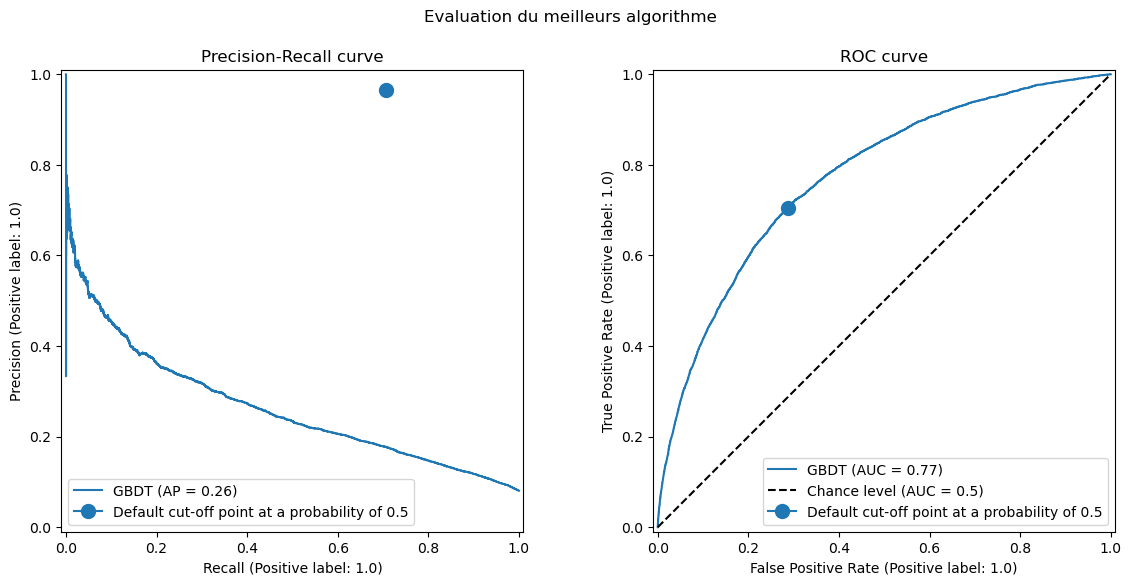

In [121]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, ax=axs[0], name="GBDT"
)
axs[0].plot(
    scoring["recall"](model, X_test, y_test),
    scoring["precision"](model, X_test, y_test),
    marker="o",
    markersize=10,
    color="tab:blue",
    label="Default cut-off point at a probability of 0.5",
)
axs[0].set_title("Precision-Recall curve")
axs[0].legend()

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test,
    ax=axs[1],
    name="GBDT",
    plot_chance_level=True,
)
axs[1].plot(
    scoring["fpr"](model, X_test, y_test),
    scoring["tpr"](model, X_test, y_test),
    marker="o",
    markersize=10,
    color="tab:blue",
    label="Default cut-off point at a probability of 0.5",
)
axs[1].set_title("ROC curve")
axs[1].legend()
_ = fig.suptitle("Evaluation du meilleurs algorithme")

plt.show()

La precision-Recal curve présente quoi ?
La ROC curve du model est bien supérieur a la diagonal, ce qui implique que le modèle fait mieux que un dummy. La forme de la Roc curve ne donne pas vraiment de possibilité d'optimisation du seuil car elle est lisse et contante.

Optimisation du seuil de décision

In [122]:
with mlflow.start_run(run_name="Test to delete"):
    tuned_model = TunedThresholdClassifierCV(
        estimator=model,
        scoring=my_scorer,
        store_cv_results=True,  # necessary to inspect all results
        response_method="auto",
    )
    tuned_model.fit(X_train, y_train)

In [129]:
# Calcul des score absolue
score_train_not_tuned = -my_scorer(model, X_train, y_train)
score_train_tuned = -my_scorer(tuned_model, X_train, y_train)
score_test_not_tuned = -my_scorer(model, X_test, y_test)
score_test_tuned = -my_scorer(tuned_model, X_test, y_test)

scores = [
          [score_train_not_tuned, score_test_not_tuned],
          [score_train_tuned, score_test_tuned]
         ]

In [130]:
scores = pd.DataFrame(scores, columns=["Entrainement", "Test"], index=["Non optimisé", "Optimisé"])

# Rapporter le score au nombre de clients dans les dataframe, car le score métier dépend de ce nombre
scores_relatif = copy.copy(scores)
scores_relatif.loc[:, "Entrainement"] = scores_relatif.loc[:, "Entrainement"]/X_train.shape[0]
scores_relatif.loc[:, "Test"] = scores_relatif.loc[:, "Test"]/X_test.shape[0]

In [157]:
print("Rapport de l'optimisation du seuil")
print("")
print(f"Seuil définit après l'optimisation : {round(tuned_model.best_threshold_,2)}")
print("")
print("Score métier pour les différents dataset")
display(scores)
print("Score métier rapportés au nombre d'individus des jeux de données")
display(scores_relatif)

Rapport de l'optimisation du seuil

Seuil définit après l'optimisation : 0.53

Score métier pour les différents dataset


,Entrainement,Test
Non optimisé,109338,30834
Optimisé,108545,30732


Score métier rapportés au nombre d'individus des jeux de données


,Entrainement,Test
Non optimisé,0.444481,0.501382
Optimisé,0.441258,0.499724


Etant données que le score métier compte le nombre de faux n'égatife et de faux positif les multiplie par un coefficient puis les sommes le score absolu dépend du nombre total de clients présent dans le dataset. Ainsi pour pouvoir  comparer entre les données utilise lors de l'entrainement et celle utiliser lors du test (deux jeux de donées qui non pas la même taille) il faut diviser le score absolu par le nombre de clients de chaque dataset.  
La dans les deux cas le score est mielleurs sur le jeu de test que d'entrainement normale ces le score sur le test qui est "regarder" par l'optimiseur.  
K'optimisation d'appporte pas une trés grande différence de socre.

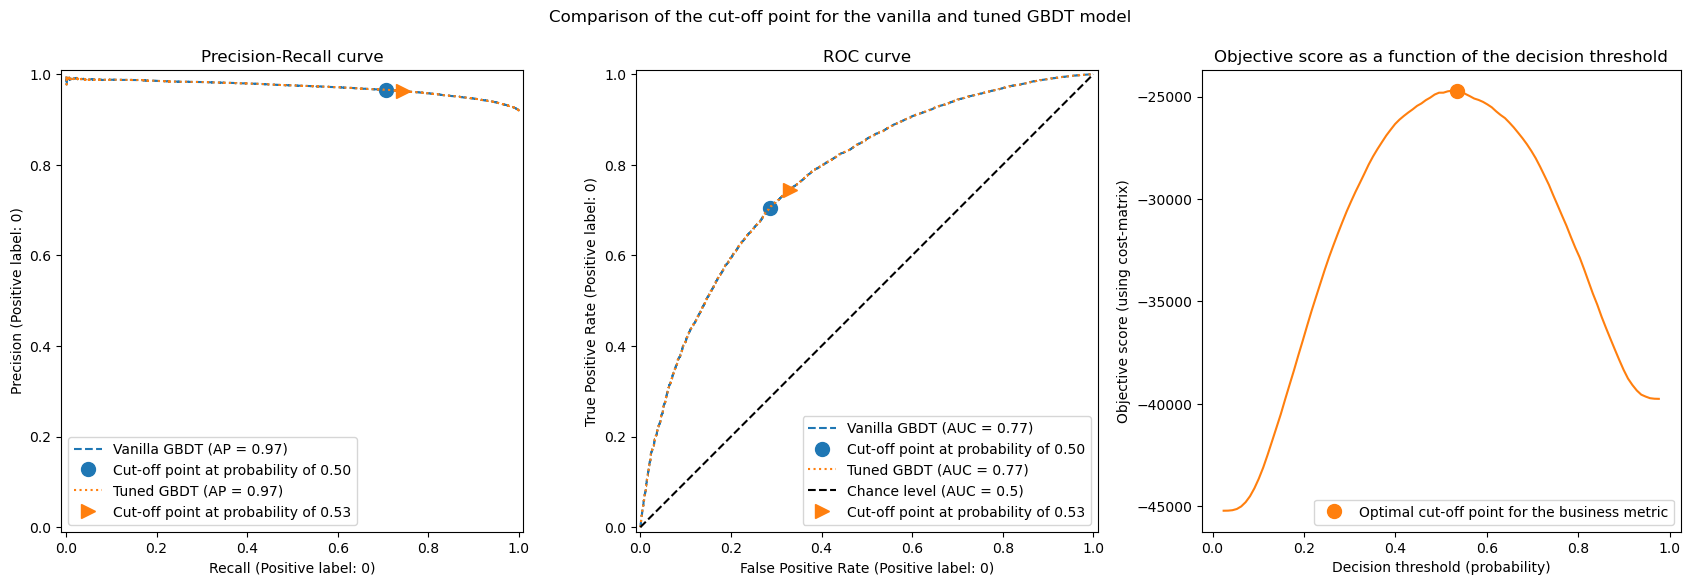

In [125]:
title = "Comparison of the cut-off point for the vanilla and tuned GBDT model"
plot_roc_pr_curves(model, tuned_model, title=title)

La courbe du score métier en fonction du seuil de décision ne présente pas de plateau ce qui indique que le model n'est pas en sur-apprentisage. La différence entre le seuil prédéfinit de sklearn qui est à 0.5 et le seuil déterminer par l'optimiseur est minime. Mais le seuil optimisé est l'apex de la courbe précédente donc celui-ci est unique.

Matrice de confusion

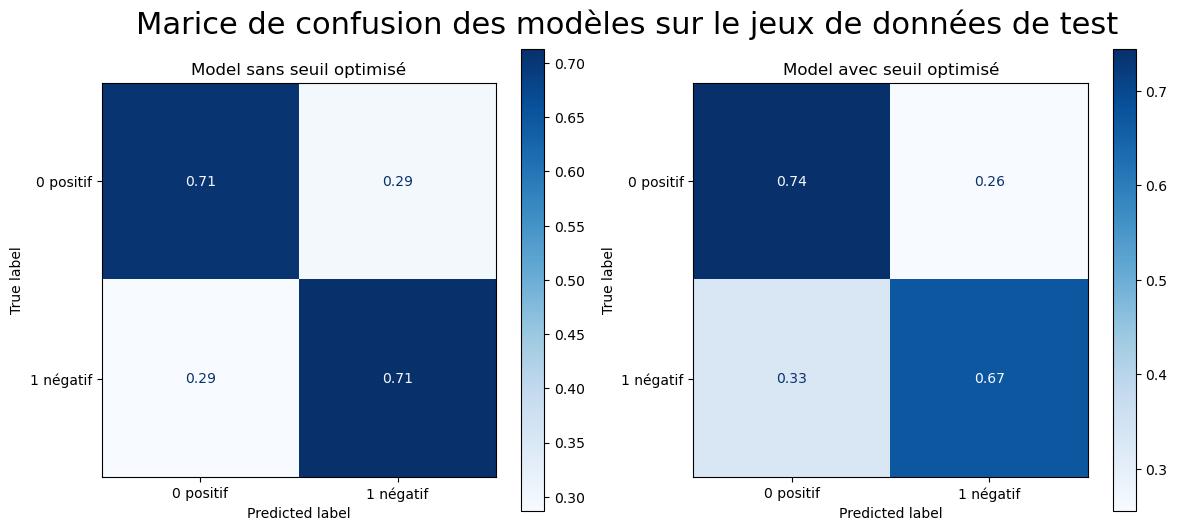

In [156]:
model_dict = {"model": model ,
              "title":"Model sans seuil optimisé"}
tuned_model_dict = {"model" : tuned_model,
                    "title" : "Model avec seuil optimisé"}

fig, axes = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(14, 6))

# idx ne sert par dans ce cas je ne me rappel plus pourquoi il est là
for idx, (ax, dico) in enumerate(zip(axes.ravel(),[model_dict, tuned_model_dict])): 
    disp = ConfusionMatrixDisplay.from_estimator(
        dico["model"],
        X_test,
        y_test,
        display_labels=["0 positif","1 négatif"],
        cmap=plt.cm.Blues,
        normalize=normalize,
        ax=ax
    )
    disp.ax_.set_title(dico["title"])
    
# Ajuster le graphique pour optimié la place utilisée
#fig.subplots_adjust(wspace=0.12, hspace=0.4, left=0.025, right=0.975, bottom=0.2, top=0.88)
# Ajouter le titre
fig.text(
        x=0.5,
        y=0.92,
        s=f"Marice de confusion des modèles sur le jeux de données de test",
        ha="center",
        va="center",
        ma="center",
        fontsize=22
    )
plt.show()

L'optimisation du seuil fait augmenter le nombre de faux positif, mais comme vue précédement les scores eux diminue un peut.

## 5. Sauver le modèle lancer le déploiment cloud

J'utilise l'ui de mlflow pour déterminer le meilleurs modèle. Puis je l'ajoute au registre de mlflow en tant que "predict_client_payment". Une fois le nom définit je pourrais charger de nouvelle version du model dans ce nom. Ensuite pour différencier les différente version stocker sous ce nom j'ajoute le tag "best" au model que je souhaite passer en prod. Cette alias me permet d'utiliser toujours le même code pour charger et déploiyer le model sur git.

### 5.1 Charger le model depuis la base de données de mlflow

In [67]:
client = MlflowClient()

In [68]:
# Nom du model à charger depuis la base de donnée de mlflow
model_name = "predict_client_payment" # Non du modèle dans le registre
model_version_alias = "best" # tag du model a exporté

# Récuperer les informations sur le model
model_info = client.get_model_version_by_alias(model_name, model_version_alias)
model_tags = model_info.tags
print(model_tags)

2026/03/05 14:28:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/05 14:28:22 INFO mlflow.store.db.utils: Updating database tables
2026/03/05 14:28:22 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/05 14:28:22 INFO alembic.runtime.migration: Will assume non-transactional DDL.


{'validation_status': 'pending', 'projet_7': 'model'}


In [69]:
# Consrtuire l'URI du model pour l'appel
model_uri = f"models:/{model_name}@{model_version_alias}"
# Charger le model avec l'URI
model = mlflow.sklearn.load_model(model_uri)

In [70]:
# Résumer de la structure du modele
print(model)

TunedThresholdClassifierCV(estimator=Pipeline(steps=[('imputer',
                                                      SimpleImputer(strategy='median')),
                                                     ('under_SMOTE',
                                                      RandomUnderSampler(random_state=42)),
                                                     ('over_SMOTE',
                                                      SMOTE(random_state=42)),
                                                     ('Scaler', MinMaxScaler()),
                                                     ('Classifier',
                                                      HistGradientBoostingClassifier(max_depth=10,
                                                                                     random_state=42))]),
                           scoring=make_scorer(my_metric, response_method='predict'),
                           store_cv_results=True)


### 5.2 Sauver le modèle charger depuis la base de donnée

Signature d'un modèle

Afin de garantir que les données d'entrée d'un modèle sont conformes à ce qui est attendu, les modèles MLflow peuvent inclure des metadatas décrivant les entrées et sorties :
- Model Signature - description des entrées et sorties du modèle
- Model Input Example - exemple d'une entrée valide

La signature du modèle permet de renseigner le nom des colonnes et leurs types afin de vérifier si ils sont similaires lors de la prédiction.

[Documentation, exemple signature](https://mlflow.org/docs/latest/ml/model/signatures/)

In [72]:
signature = infer_signature(X_train, y_train)

D:\Users\SUZON\AppData\Local\anaconda3\envs\projet_7_python_3_11_14\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [ ]:
# requierement pour le fonctionnement de model
requirements = {
                "name": "projet_7_python_3_11_14",
                "channels": ["conda-forge"],
                "dependencies": [
                    "python=3.3.7",
                    {
                        "pip": [
                            "pandas==2.3.3",
                            "numpy==1.26.4",
                            "mlflow==3.7.0",
                            "imbalanced-learn==0.14.1",
                            "scikit-learn==1.8.0",
                            "cloudpickle==3.1.2",
                            "psutil==7.2.2",
                            "pyarrow==12.0.0",
                        ],
                    },
                ],
            }

#### 5.2.1 Stoker le model pour le local

In [ ]:
# Stocker le model en local
# Nom du modele pour le stokage
model_directory_name = "best_SMOTE_V2.2" 
# Chemin absolu vers le repertoire local de stockage
local_save_directory_path = r".\data\modeles\"

# Sauver le model
mlflow.sklearn.save_model(model, os.path.join(local_save_directory_path, model_directory_name), 
                          signature=signature, pyfunc_predict_fn="predict", 
                          conda_env=requirements)

#### 5.2.2 Déposer le model dans le dossier de l'application pour déploiment

In [73]:
# Nom du modele pour le stokage
app_model_directory_name = "mlflow_to_deploy"
# Stocker le model pour déploiemnt dans l'application
app_save_directory_path = r"./app/mlflow_api/mlflow_to_deploy"

# Remplacer l'ancient model avec le nouveau
# !! Supprimer le dossier avant d'exporter a nouveau le model
mlflow.sklearn.save_model(model, os.path.join(app_save_directory_path, app_model_directory_name),
                          signature=signature, pyfunc_predict_fn="predict",
                          conda_env=requirements)

## 6. Data drift with evidently
[Site du package](https://docs.evidentlyai.com/introduction)

###6.1  Application a mon cas d'usage  
Je doit comparer les dataset :
- application_train, le dataset d'entrainement : data
- application_test, le dataset de prod : data_test  

Les deux jeux de donnnées on été transformer de la même manière

### 6.2 Donner à evidently le type des colonnes du dataset  
Les variable catégoriel on été encoder lors du feature engineering donc il n'y a plus de colonne catégoriel a proprement parler

In [58]:
schema = DataDefinition(
    numerical_columns=data.iloc[: ,2:].columns.to_list(),
    )

### 6.3 Create Evidently Datasets to work with

In [59]:
eval_data_1 = Dataset.from_pandas(
    pd.DataFrame(data.iloc[: ,2:]),
    data_definition=schema
)

In [60]:
eval_data_2 = Dataset.from_pandas(
    pd.DataFrame(data_test.iloc[: ,2:]),
    data_definition=schema
)

Eval_data_2 est la référence contre la quelle on mesure le datadrift 

### 6.4 Calculer le rapport

In [61]:
report = Report([
    DataDriftPreset() 
])

my_eval = report.run(eval_data_1, eval_data_2)

### 6.5 Exporter le rapport

In [62]:
# Export report in html
my_eval.save_html("DataDrift_Trin_vs_test.html")